In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/spam.csv',encoding='latin-1')

In [ ]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.isna().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [ ]:
df=df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"])

In [ ]:
df.head(2)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [ ]:
df.shape

(5572, 2)

In [ ]:
df.columns=["target","text"]

In [ ]:
df.head(2)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [ ]:
df["target"]=df["target"].map({"ham":0,"spam":1})

In [ ]:
df.head(4)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...


# Preprocessing

In [ ]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
def transform_text(text):
  #convert to lower text
  text=text.lower()
  stemmer=PorterStemmer()
  #Toeknization
  tokenized_text=nltk.word_tokenize(text)
  #cleaning and stemming
  y=[]
  for word in tokenized_text:
    if word.isalnum() and word not in stopwords.words('english'):
      y.append(stemmer.stem(word))
  return " ".join(y)



In [ ]:
df["transform_text"]=df["text"].apply(transform_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf=TfidfVectorizer(max_features=3000)
x=tfidf.fit_transform(df["transform_text"]).toarray()
y=df["target"].values

**Traning the model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
#train the model
mnb=MultinomialNB()
mnb.fit(X_train,y_train)

MultinomialNB()

## Predictions

In [ ]:
y_pred=mnb.predict(X_test)

# Evaluation

In [ ]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Precision: ",precision_score(y_test,y_pred))

Accuracy:  0.9650224215246637
Precision:  0.9917355371900827


# Prediciting a new message

In [ ]:
def predict_spam(msg):
  transformed=transform_text(msg)
  vectorized=tfidf.transform([transformed])
  result=mnb.predict(vectorized)[0]
  return "SPAM" if result ==1 else "NOT SPAM"


In [ ]:
print(predict_spam("alert! you have been hacked,to secure your account call and text the following number."))

SPAM


In [ ]:
import numpy as np

# Get the words from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Get the log probabilities from the Naive Bayes model
# [1] represents the 'Spam' class
spam_probabilities = mnb.feature_log_prob_[1]

# Sort them to find the top words
top_spam_indices = np.argsort(spam_probabilities)[-10:]
top_spam_words = [feature_names[i] for i in top_spam_indices]

print("Top 10 'Spammiest' words according to your model:")
print(top_spam_words)

Top 10 'Spammiest' words according to your model:
['repli', 'prize', 'stop', 'ur', 'text', 'claim', 'mobil', 'txt', 'free', 'call']


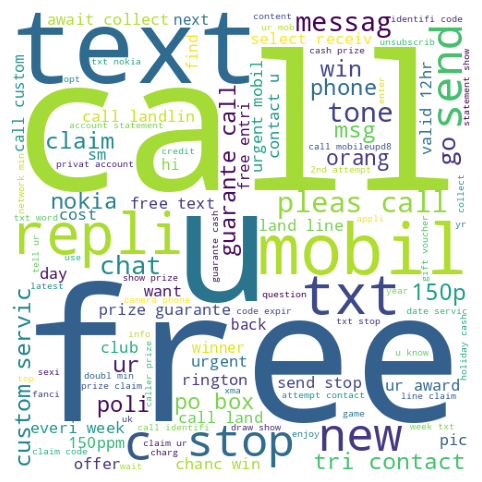

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate a Word Cloud for Spam messages
spam_wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_text = df[df['target'] == 1]['transform_text'].str.cat(sep=" ")
spam_cloud = spam_wc.generate(spam_text)

plt.figure(figsize=(10,6))
plt.imshow(spam_cloud)
plt.axis("off")
plt.show()